In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
from shapely.geometry import shape

def load_data():
    # Load religion data
    religion_df = pd.read_csv('religion.csv')
    
    # Load GeoJSON manually to ensure compatibility
    with open('localboundries.json', 'r') as f:
        data = json.load(f)
    
    features = data['features']
    geoms = [shape(f['geometry']) for f in features]
    props = [f['properties'] for f in features]
    
    gdf = gpd.GeoDataFrame(props, geometry=geoms)
    gdf.crs = "EPSG:4326"
    return religion_df, gdf

def get_user_choice():
    religions = ['Hindu', 'Buddhist', 'Islam', 'Kirat', 'Christian', 'Prakriti', 'Bon', 'Jain', 'Baha’i', 'Sikh']
    print("\nSelect Religion:")
    for i, r in enumerate(religions, 1):
        print(f"{i}. {r}")
    rel_idx = int(input("Enter number (1-10): ")) - 1
    selected_religion = religions[rel_idx]

    provinces = ['Koshi', 'Madhesh', 'Bagmati', 'Gandaki', 'Lumbini', 'Karnali', 'Sudurpashchim']
    print("\nSelect Province:")
    for i, p in enumerate(provinces, 1):
        print(f"{i}. {p}")
    prov_idx = int(input("Enter number (1-7): ")) - 1
    selected_province = provinces[prov_idx]

    print("\nSelect View Mode:")
    print("1. Percentage Wise (%)")
    print("2. Population Wise (Count)")
    mode_idx = input("Enter number (1-2): ")
    selected_mode = "percentage" if mode_idx == "1" else "population"

    return selected_religion, selected_province, selected_mode

def generate_map(religion, province_name, mode, religion_df, gdf):
    province_map = {
        '1': 'Koshi', '2': 'Madhesh', '5': 'Lumbini',
        'Bagmati': 'Bagmati', 'Gandaki': 'Gandaki', 
        'Karnali': 'Karnali', 'Sudur Pashchim': 'Sudurpashchim'
    }
    district_corr = {'Dhanusa': 'DHANUSHA', 'Kavrepalanchok': 'KABHREPALANCHOK', 'Makwanpur': 'MAKAWANPUR'}

    # 1. CALCULATE GLOBAL LIMITS FOR UNIFORMITY
    if mode == "percentage":
        vmin = religion_df[religion].min()
        vmax = religion_df[religion].max()
        plot_col = religion
        title_suffix = "(%)"
    else:
        # Calculate population for all districts first to find the national peak
        religion_df['temp_pop'] = (religion_df[religion] * religion_df['(Total)']) / 100
        vmin = religion_df['temp_pop'].min()
        vmax = religion_df['temp_pop'].max()
        plot_col = f'{religion}_Pop'
        title_suffix = "(Count)"

    # 2. PREPARE DATA
    religion_df['District_Match'] = religion_df['District'].replace(district_corr).str.upper()
    gdf['DISTRICT_Match'] = gdf['DISTRICT'].str.upper()
    gdf['Province_Name'] = gdf['Province'].map(province_map)
    
    # Filter and Dissolve
    prov_gdf = gdf[gdf['Province_Name'] == province_name].copy()
    dist_gdf = prov_gdf.dissolve(by='DISTRICT_Match')
    merged = dist_gdf.merge(religion_df, left_index=True, right_on='District_Match')
    
    if mode == "population":
        merged[plot_col] = (merged[religion] * merged['(Total)']) / 100

    # 3. PLOTTING WITH UNIFORM LIMITS (vmin, vmax)
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    merged.plot(column=plot_col, 
                cmap='YlOrRd', 
                legend=True, 
                vmin=vmin, 
                vmax=vmax,
                legend_kwds={'label': f"{religion} {title_suffix} (Scale: National Min to Max)"},
                edgecolor='black', linewidth=0.6, ax=ax)
    
    for idx, row in merged.iterrows():
        point = row['geometry'].representative_point()
        ax.text(point.x, point.y, row['District'], fontsize=8, ha='center', weight='bold')

    plt.title(f"{religion} Distribution in {province_name}\n(Uniform scale based on all-Nepal data: {vmin:.1f} to {vmax:.1f})", fontsize=14)
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    print("Initializing mapping data...")
    rel_df, geo_df = load_data()
    
    while True:
        try:
            religion, province, mode = get_user_choice()
            generate_map(religion, province, mode, rel_df, geo_df)
            
            if input("\nGenerate another map? (y/n): ").lower() != 'y':
                break
        except Exception as e:
            print(f"An error occurred: {e}. Please try again.")


--- Select Religion ---
1. Hindu
2. Buddhist
3. Islam
4. Kirat
5. Christian
6. Prakriti
7. Bon
8. Jain
9. Baha’i
10. Sikh


Enter choice (1-10):  3



--- Select Province ---
1. Koshi
2. Madhesh
3. Bagmati
4. Gandaki
5. Lumbini
6. Karnali
7. Sudurpashchim


Enter choice (1-7):  1



--- Select View Mode ---
1. percentage
2. population


Enter choice (1-2):  1



Success! Map saved as: Islam_Koshi_percentage.png


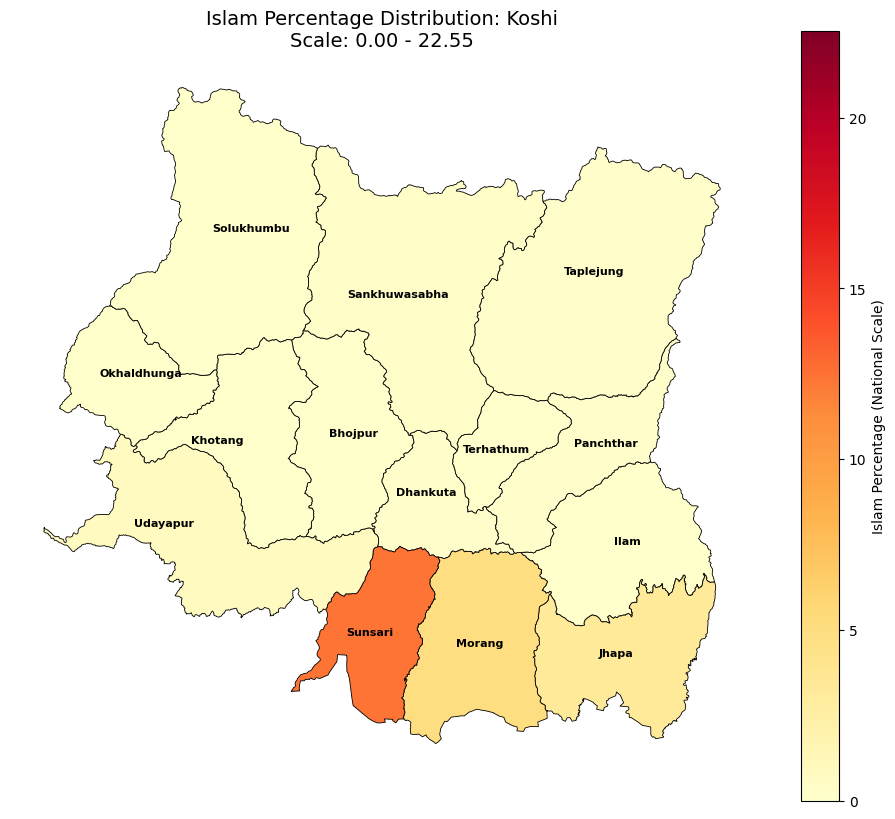


Create another map? (y/n):  y



--- Select Religion ---
1. Hindu
2. Buddhist
3. Islam
4. Kirat
5. Christian
6. Prakriti
7. Bon
8. Jain
9. Baha’i
10. Sikh


Enter choice (1-10):  3



--- Select Province ---
1. Koshi
2. Madhesh
3. Bagmati
4. Gandaki
5. Lumbini
6. Karnali
7. Sudurpashchim


Enter choice (1-7):  2



--- Select View Mode ---
1. percentage
2. population


Enter choice (1-2):  1



Success! Map saved as: Islam_Madhesh_percentage.png


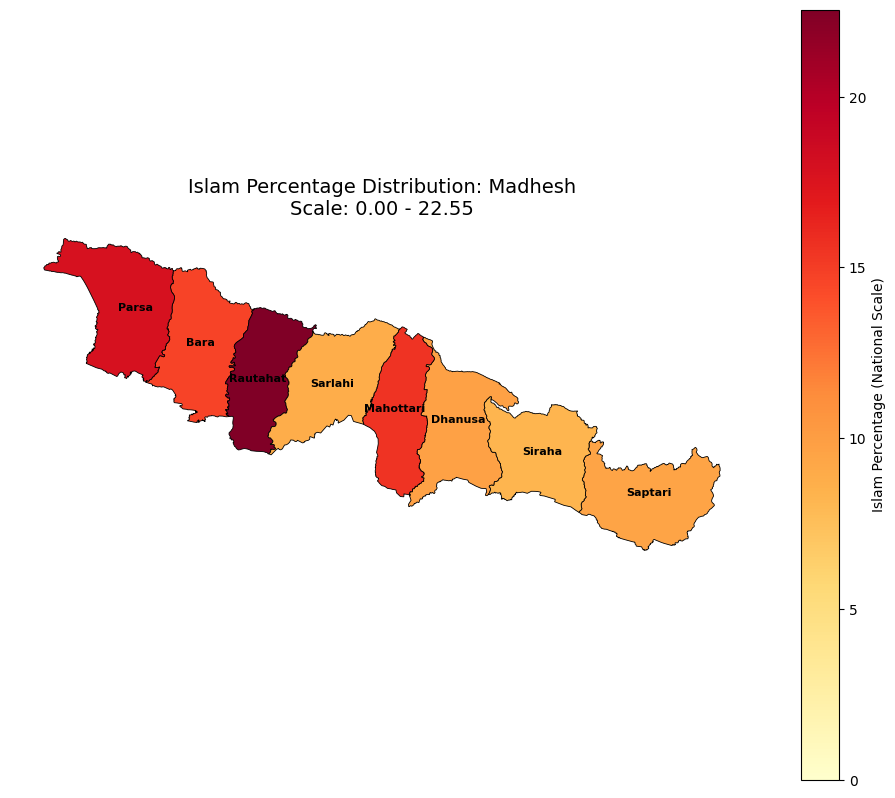


Create another map? (y/n):  y



--- Select Religion ---
1. Hindu
2. Buddhist
3. Islam
4. Kirat
5. Christian
6. Prakriti
7. Bon
8. Jain
9. Baha’i
10. Sikh


Enter choice (1-10):  3



--- Select Province ---
1. Koshi
2. Madhesh
3. Bagmati
4. Gandaki
5. Lumbini
6. Karnali
7. Sudurpashchim


Enter choice (1-7):  3



--- Select View Mode ---
1. percentage
2. population


Enter choice (1-2):  1



Success! Map saved as: Islam_Bagmati_percentage.png


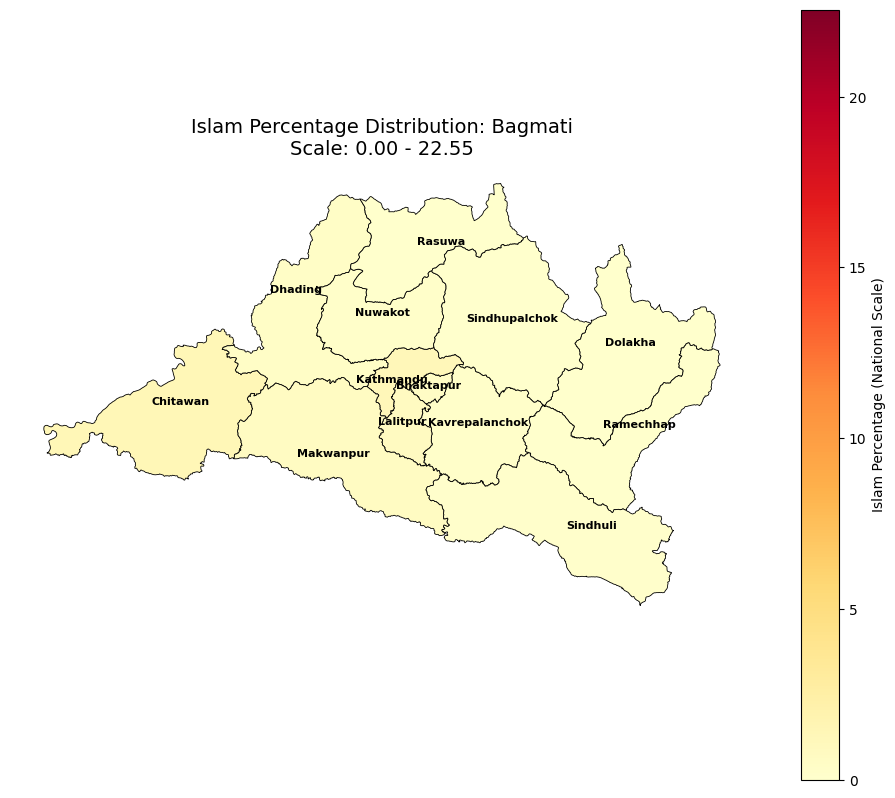


Create another map? (y/n):  y



--- Select Religion ---
1. Hindu
2. Buddhist
3. Islam
4. Kirat
5. Christian
6. Prakriti
7. Bon
8. Jain
9. Baha’i
10. Sikh


Enter choice (1-10):  3



--- Select Province ---
1. Koshi
2. Madhesh
3. Bagmati
4. Gandaki
5. Lumbini
6. Karnali
7. Sudurpashchim


Enter choice (1-7):  4



--- Select View Mode ---
1. percentage
2. population


Enter choice (1-2):  1



Success! Map saved as: Islam_Gandaki_percentage.png


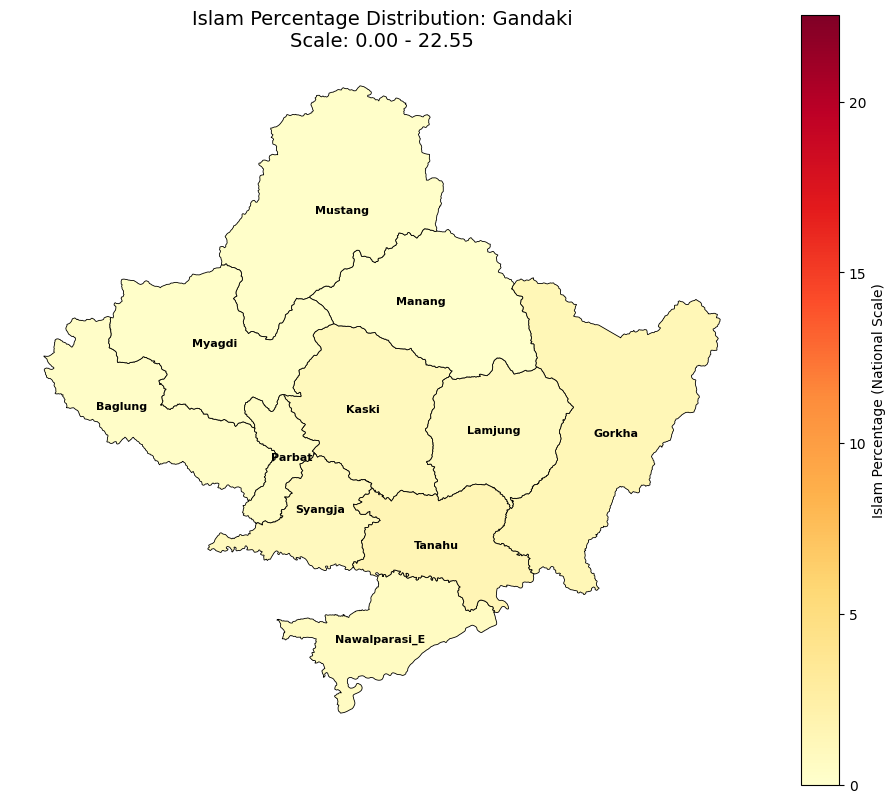


Create another map? (y/n):  y



--- Select Religion ---
1. Hindu
2. Buddhist
3. Islam
4. Kirat
5. Christian
6. Prakriti
7. Bon
8. Jain
9. Baha’i
10. Sikh


Enter choice (1-10):  3



--- Select Province ---
1. Koshi
2. Madhesh
3. Bagmati
4. Gandaki
5. Lumbini
6. Karnali
7. Sudurpashchim


Enter choice (1-7):  5



--- Select View Mode ---
1. percentage
2. population


Enter choice (1-2):  1



Success! Map saved as: Islam_Lumbini_percentage.png


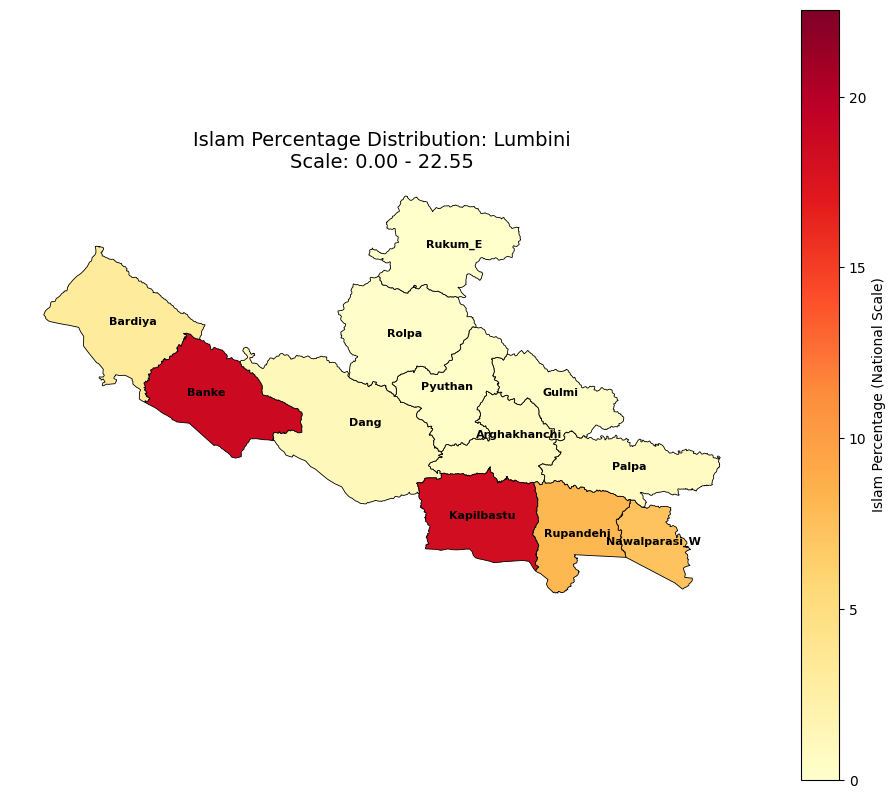


Create another map? (y/n):  y



--- Select Religion ---
1. Hindu
2. Buddhist
3. Islam
4. Kirat
5. Christian
6. Prakriti
7. Bon
8. Jain
9. Baha’i
10. Sikh


Enter choice (1-10):  3



--- Select Province ---
1. Koshi
2. Madhesh
3. Bagmati
4. Gandaki
5. Lumbini
6. Karnali
7. Sudurpashchim


Enter choice (1-7):  6



--- Select View Mode ---
1. percentage
2. population


Enter choice (1-2):  1



Success! Map saved as: Islam_Karnali_percentage.png


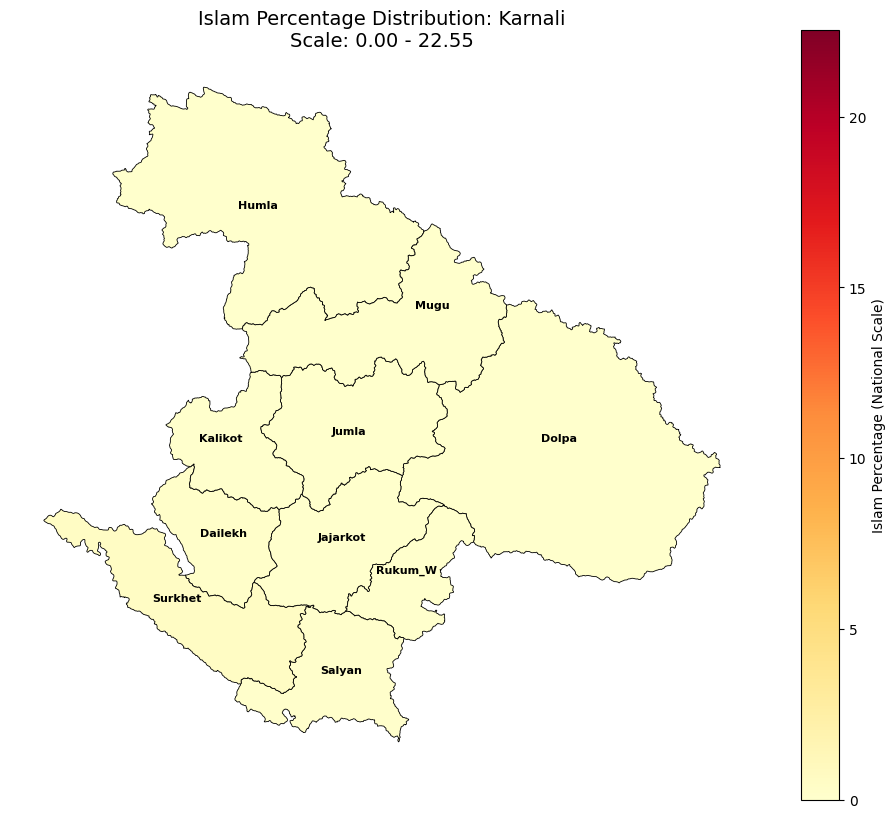


Create another map? (y/n):  y



--- Select Religion ---
1. Hindu
2. Buddhist
3. Islam
4. Kirat
5. Christian
6. Prakriti
7. Bon
8. Jain
9. Baha’i
10. Sikh


Enter choice (1-10):  3



--- Select Province ---
1. Koshi
2. Madhesh
3. Bagmati
4. Gandaki
5. Lumbini
6. Karnali
7. Sudurpashchim


Enter choice (1-7):  7



--- Select View Mode ---
1. percentage
2. population


Enter choice (1-2):  1



Success! Map saved as: Islam_Sudurpashchim_percentage.png


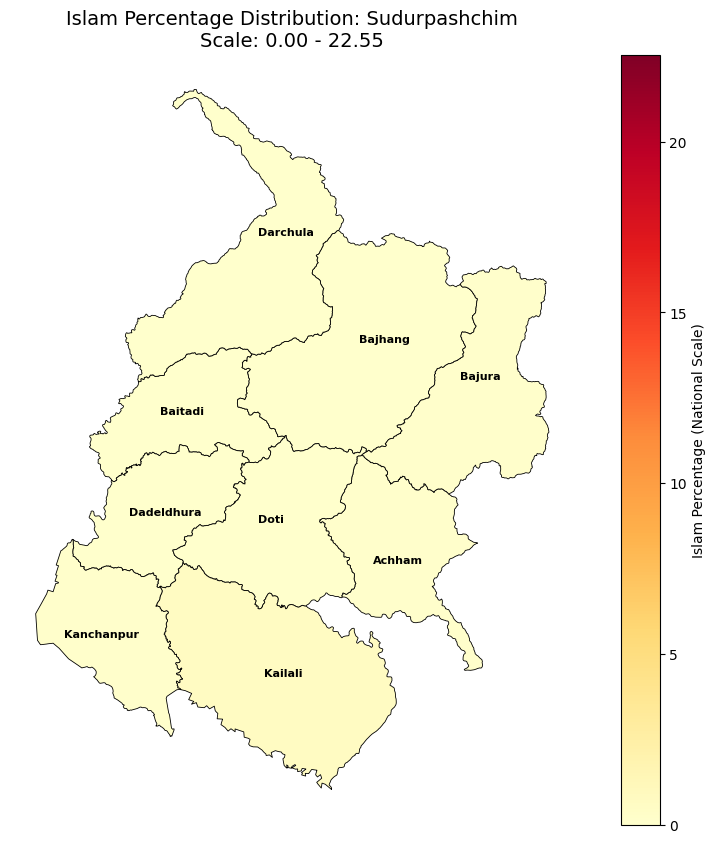


Create another map? (y/n):  n


In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
from shapely.geometry import shape

def load_data():
    # Load data files
    religion_df = pd.read_csv('religion.csv')
    with open('localboundries.json', 'r') as f:
        data = json.load(f)
    
    # Process GeoJSON features
    features = data['features']
    geoms = [shape(f['geometry']) for f in features]
    props = [f['properties'] for f in features]
    
    gdf = gpd.GeoDataFrame(props, geometry=geoms)
    gdf.crs = "EPSG:4326"
    return religion_df, gdf

def get_user_choice():
    religions = ['Hindu', 'Buddhist', 'Islam', 'Kirat', 'Christian', 'Prakriti', 'Bon', 'Jain', 'Baha’i', 'Sikh']
    print("\n--- Select Religion ---")
    for i, r in enumerate(religions, 1):
        print(f"{i}. {r}")
    rel_idx = int(input("Enter choice (1-10): ")) - 1
    selected_religion = religions[rel_idx]

    provinces = ['Koshi', 'Madhesh', 'Bagmati', 'Gandaki', 'Lumbini', 'Karnali', 'Sudurpashchim']
    print("\n--- Select Province ---")
    for i, p in enumerate(provinces, 1):
        print(f"{i}. {p}")
    prov_idx = int(input("Enter choice (1-7): ")) - 1
    selected_province = provinces[prov_idx]

    print("\n--- Select View Mode ---")
    print("1. percentage")
    print("2. population")
    mode_choice = input("Enter choice (1-2): ")
    selected_mode = "percentage" if mode_choice == "1" else "population"

    return selected_religion, selected_province, selected_mode

def generate_map(religion, province_name, mode, religion_df, gdf):
    # Mapping for internal data consistency
    province_map = {
        '1': 'Koshi', '2': 'Madhesh', '5': 'Lumbini',
        'Bagmati': 'Bagmati', 'Gandaki': 'Gandaki', 
        'Karnali': 'Karnali', 'Sudur Pashchim': 'Sudurpashchim'
    }
    district_corr = {'Dhanusa': 'DHANUSHA', 'Kavrepalanchok': 'KABHREPALANCHOK', 'Makwanpur': 'MAKAWANPUR'}

    # 1. CALCULATE NATIONAL LIMITS FOR UNIFORMITY
    if mode == "percentage":
        vmin, vmax = religion_df[religion].min(), religion_df[religion].max()
        plot_col = religion
    else:
        religion_df['total_pop_calc'] = (religion_df[religion] * religion_df['(Total)']) / 100
        vmin, vmax = religion_df['total_pop_calc'].min(), religion_df['total_pop_calc'].max()
        plot_col = 'total_pop_calc'

    # 2. DATA MERGING
    religion_df['District_Match'] = religion_df['District'].replace(district_corr).str.upper()
    gdf['DISTRICT_Match'] = gdf['DISTRICT'].str.upper()
    gdf['Province_Name'] = gdf['Province'].map(province_map)
    
    prov_gdf = gdf[gdf['Province_Name'] == province_name].copy()
    dist_gdf = prov_gdf.dissolve(by='DISTRICT_Match')
    merged = dist_gdf.merge(religion_df, left_index=True, right_on='District_Match')
    
    if mode == "population":
        merged[plot_col] = (merged[religion] * merged['(Total)']) / 100

    # 3. PLOTTING
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    merged.plot(column=plot_col, cmap='YlOrRd', legend=True, vmin=vmin, vmax=vmax,
                legend_kwds={'label': f"{religion} {mode.capitalize()} (National Scale)"},
                edgecolor='black', linewidth=0.6, ax=ax)
    
    for idx, row in merged.iterrows():
        point = row['geometry'].representative_point()
        ax.text(point.x, point.y, row['District'], fontsize=8, ha='center', weight='bold')

    plt.title(f"{religion} {mode.capitalize()} Distribution: {province_name}\nScale: {vmin:.2f} - {vmax:.2f}", fontsize=14)
    plt.axis('off')

    # 4. SAVE WITH REQUESTED NAMING CONVENTION
    filename = f"{religion}_{province_name}_{mode}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\nSuccess! Map saved as: {filename}")
    plt.show()

if __name__ == "__main__":
    rel_df, geo_df = load_data()
    while True:
        try:
            r, p, m = get_user_choice()
            generate_map(r, p, m, rel_df, geo_df)
            if input("\nCreate another map? (y/n): ").lower() != 'y':
                break
        except Exception as e:
            print(f"Error: {e}")

In [9]:
import pandas as pd
a = 'Islam'
# Load the dataset
df = pd.read_csv('religion.csv')

# Sort by 'Christian' percentage in descending order
sorted_df = df[['District', a]].sort_values(by=a, ascending=False)

# Print in the requested format: (district)=(percent)%
for index, row in sorted_df.iterrows():
    print(f"{row['District']}={row[a]}%")

Rautahat=22.55%
Banke=18.66%
Kapilbastu=18.21%
Parsa=17.8%
Mahottari=15.55%
Bara=14.71%
Sunsari=12.34%
Dhanusa=9.69%
Saptari=9.6%
Sarlahi=8.89%
Siraha=8.28%
Rupandehi=8.09%
Nawalparasi_W=7.24%
Morang=4.94%
Jhapa=3.33%
Bardiya=3.12%
Tanahu=1.56%
Gorkha=1.35%
Chitawan=1.33%
Kathmandu=1.29%
Dang=1.06%
Kaski=1.04%
Syangja=0.9%
Udayapur=0.8%
Lamjung=0.77%
Lalitpur=0.73%
Makwanpur=0.7%
Arghakhanchi=0.68%
Nawalparasi_E=0.67%
Kailali=0.64%
Palpa=0.62%
Surkhet=0.6%
Bhaktapur=0.49%
Parbat=0.47%
Dhading=0.41%
Baglung=0.34%
Pyuthan=0.34%
Sankhuwasabha=0.31%
Gulmi=0.22%
Myagdi=0.22%
Nuwakot=0.2%
Mustang=0.19%
Kavrepalanchok=0.19%
Dailekh=0.19%
Achham=0.14%
Rolpa=0.12%
Salyan=0.12%
Kanchanpur=0.1%
Dhankuta=0.1%
Sindhuli=0.1%
Panchthar=0.1%
Taplejung=0.09%
Bajura=0.09%
Ilam=0.08%
Jumla=0.08%
Dolpa=0.07%
Dolakha=0.06%
Doti=0.06%
Rukum_W=0.06%
Dadeldhura=0.05%
Manang=0.05%
Sindhupalchok=0.04%
Jajarkot=0.04%
Darchula=0.03%
Rasuwa=0.03%
Ramechhap=0.03%
Bhojpur=0.02%
Terhathum=0.02%
Mugu=0.02%
Solukhumbu=

# 